In [46]:
# importing cfd_jacobian module
# remember to pip install pyau3d in conda
import numpy as np
from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import pandas as pd

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigs

from pyau3d.pv.vtktool import pdata
%matplotlib widget

Boundary list file construction 

key components
- area normals of surface
- face center coord

try with one surface first


In [47]:
# loading files

def specific_energy(rho, p, ux, uy, uz, gamma=1.4):
    return p / ((gamma - 1.0) * rho) + 0.5 * (ux**2 + uy**2 + uz**2)

def conservative_variables(rst, GAMMA):
    """Return conservative variables U on the surface."""
    E = specific_energy(rst.rho, rst.p, rst.ux, rst.uy, rst.uz, GAMMA)

    U = np.column_stack((
        rst.rho,
        rst.rho * rst.ux,
        rst.rho * rst.uy,
        rst.rho * rst.uz,
        rst.rho * E
    ))
    return U

# Read neccessary files
Mesh = 765960
Re   = 60
Mach = 0.73
gamma = 1.4
R_gas = 287.0          # confirm units match the solver
mesh_ver = 3
case_name = "OAT"

# dir = f"C:/Users/User/Git/flux_jacobian/cases/v{mesh_ver}_mesh/cylinder_{Mesh}_Re{Re}_M{Mach}"
# dir = f"/home/ahf25/CFD_2d_cylinder_all/Steady/Ma{Mach}/v{mesh_ver}_mesh/2d_cylinder_{Mesh}_Re{Re}" 
# dir = f"/home/ahf25/OAT15/OAT15_M0.73_A35" 

dir = "C:/Users/User/Git/flux_jacobian/cases/OAT15/OAT15_M0.73_A35"
pltfile = PltFileUtils(f"{dir}/{case_name}.plt")
rstfile = UnkFileUtils(f"{dir}/{case_name}.unk", extend=False)  # both rst and unk are fine

fortfile = pd.read_csv(f"{dir}/fort.864", sep=r'\s+', header=None).to_numpy()

rstfile._primitive()
U_list = conservative_variables(rstfile, gamma)
coord  = pltfile.coord

In [48]:
def area_normals(coord, ifac3=None, ifac4=None):
    """
    Compute area-weighted normal vectors (Ax, Ay, Az) at each nodes,
    accumulated from triangle and/or quadrilateral faces. No PolyData is
    built; only the (N, 3) array is returned.
 
    For each face, the area-normal vector is:
        triangle : 0.5 * cross(v1 - v0, v2 - v0)
        quad     : sum of the two triangle area-normals from splitting
                   the quad (0,1,2) + (0,2,3)
    Each face's area-normal is split equally among its vertices and summed.

    That is how it accounted from the node-centered formulation
 
    Args:
        coord : (N, 3) array of mesh point coordinates
        ifac3 : (M3, 3) array of triangle connectivity, zero-based (or None)
        ifac4 : (M4, 4) array of quad connectivity, zero-based (or None)
 
    Returns:
        anor : (N, 3) array of area-weighted normals (Ax, Ay, Az) per point
    """
    coord = np.asarray(coord, dtype=float)
    anor = np.zeros_like(coord)
 
    if ifac3 is not None and len(ifac3) > 0:
        ifac3 = np.asarray(ifac3)
        v0, v1, v2 = coord[ifac3[:, 0]], coord[ifac3[:, 1]], coord[ifac3[:, 2]]
        face_anor = 0.5 * np.cross(v1 - v0, v2 - v0)   # (M3, 3)
        contrib = -face_anor / 3.0                      # sign matches ref code
        for k in range(3):
            np.add.at(anor, ifac3[:, k], contrib)
 
    if ifac4 is not None and len(ifac4) > 0:
        ifac4 = np.asarray(ifac4)
        v0, v1, v2, v3 = (coord[ifac4[:, 0]], coord[ifac4[:, 1]],
                          coord[ifac4[:, 2]], coord[ifac4[:, 3]])
        n1 = 0.5 * np.cross(v1 - v0, v2 - v0)
        n2 = 0.5 * np.cross(v2 - v0, v3 - v0)
        face_anor = n1 + n2                              # (M4, 3)
        contrib = -face_anor / 4.0
        for k in range(4):
            np.add.at(anor, ifac4[:, k], contrib)
 
    return anor

In [66]:
# verify area_normals function by checking sum of area normals for cylinder surface (flag  = 7)

# for cylinder surface (flag = 7) The sum of all area normals should be close to zero
# for inlet surface (flag = 1) The sum of all area normals should be close to -1

# extract the nodes, tri-connectivity and quad-connectivity of a surface

flag = 4

global_surface_nodes, ifac3, ifac4 = pltfile.extract_surface_real(flag = flag)

# get surface coordinates (0 based indexing)
global_surface_coord = coord[global_surface_nodes]

# get area_normals
surface_area_normals = area_normals(global_surface_coord, ifac3, ifac4)

print(f"Sum of area normals of flag = {flag}: ", surface_area_normals.sum(axis=0))

n_hat = surface_area_normals / np.linalg.norm(surface_area_normals, axis=1, keepdims=True)




Sum of area normals of flag = 4:  [-2.50000000e+01 -1.40165657e-15  0.00000000e+00]


Surface nodes:  [498985 498984 512979 498987 498986 512981 512984 498990 498991 512987
 498992 498993 512992 498998 498999 499001 512994 499000 499002 512996
 499003 499004 512998 499005 499006 499007 513000 499009 513003 499008
 499010 499011 513005 499012 499013 513006 513002 499033 499014 499015
 513008 499016 499017 513010 499112 499020 499021 513014 513016 499023
 499022 499029 513020 499028 499031 513022 499030 513025 499032 499035
 499034 513027 499036 513028 499037 513024 499053 512986 499187 513035
 499042 499043 513036 499045 499044 513038 499046 499146 499049 513039
 499050 499051 513041 499052 513043 499054 513049 499059 499259 513040
 499077 513047 499058 499057 513001 499208 513050 499060 499113 513034
 513052 499061 499062 499063 513053 499064 499067 513057 499068 513051
 499095 499093 513083 499070 499069 513060 499072 513061 499071 499256
 499266 499164 513037 513066 499075 499076 499081 513071 513067 499078
 513048 499136 499083 513073 499087 499303 499079 513069 4990

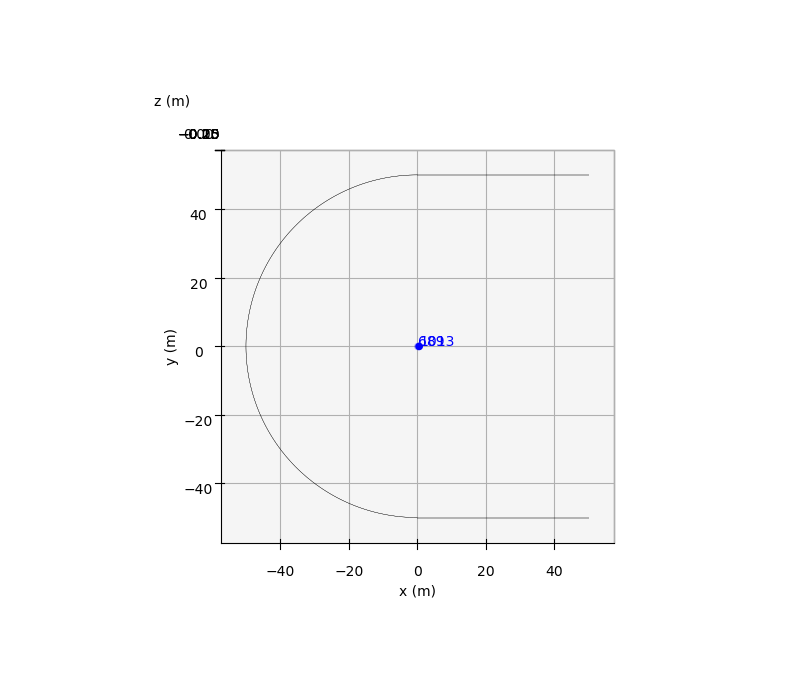

In [67]:
# plot the surface to verify

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="3d")

x = global_surface_coord[:, 0]
y = global_surface_coord[:, 1]
z = global_surface_coord[:, 2]

# convert ifac3 to np array 
tris = np.asarray(ifac3)

ax.plot_trisurf(x, y, z, triangles=tris, edgecolor="k", linewidth=0.2, alpha=0.8)
# label each node with its index
# for i in range(len(x)):
#     ax.text(x[i], y[i], z[i], str(global_surface_nodes[i]), fontsize=10, color="red")

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")

print("Surface nodes: ",global_surface_nodes)

neighbors = [689, 1013]
neighbors_coord = coord[neighbors]

print("Neighbour coordinates: ", neighbors_coord)

# plot the neighbouring coordinates
xn = neighbors_coord[:, 0]
yn = neighbors_coord[:, 1]
zn = neighbors_coord[:, 2]

for i in range(len(xn)):
    ax.text(xn[i], yn[i], zn[i], str(neighbors[i]), fontsize=10, color="blue")

ax.scatter(xn,yn,zn, c  = "blue")
ax.view_init(elev=90, azim=-90)   # look straight down the Z axis → XY plane
ax.set_proj_type('ortho')          # parallel projection, no perspective distortion
ax.set_aspect('equal')

Verification of fortfile 
- ensure the first column of fortfile is one-based
- observe the nodes on the boundary surface
- compare to the neighbours as stated in the fortfile

Important notes
- fortfile: column 1 is 1-based
- all pyau3d related data and functions are 0-based index

In [51]:
'''
From the surface plot of inlet surface (flag = 1)

node 1362 is connected to 1363, 1374, 1380 --> 0 based index

switch to 1-based index

node 1363 is connected to 1364, 1375, 1381

note that ifac3 is a local node connectivity, it is reseted to zero based index, cannot be used


it could be verify by the i = 1363 of the fortfile
now we know that the fortfile is legit 

      690      1363  6.687455E-03  2.431095E-03  3.826594E-02  5.779577E-02

      1014      1363  4.091500E-03 -4.621736E-03  2.389505E-02  1.565888E-02


      1363      1381 -4.109657E-03  0.000000E+00 -9.805075E-02  9.805075E-03
      1363      1364 -1.862208E-03 -4.621736E-03 -2.513032E-02  9.805075E-03
      1363      1375  3.121913E-04  2.431095E-03 -1.075943E-02  9.805075E-03

1381, 1364, 1375 are on the boundary
690, 1014 are inside the domain --> 689, 1013 (in zero-based index)
      
'''

'\nFrom the surface plot of inlet surface (flag = 1)\n\nnode 1362 is connected to 1363, 1374, 1380 --> 0 based index\n\nswitch to 1-based index\n\nnode 1363 is connected to 1364, 1375, 1381\n\nnote that ifac3 is a local node connectivity, it is reseted to zero based index, cannot be used\n\n\nit could be verify by the i = 1363 of the fortfile\nnow we know that the fortfile is legit \n\n      690      1363  6.687455E-03  2.431095E-03  3.826594E-02  5.779577E-02\n\n      1014      1363  4.091500E-03 -4.621736E-03  2.389505E-02  1.565888E-02\n\n\n      1363      1381 -4.109657E-03  0.000000E+00 -9.805075E-02  9.805075E-03\n      1363      1364 -1.862208E-03 -4.621736E-03 -2.513032E-02  9.805075E-03\n      1363      1375  3.121913E-04  2.431095E-03 -1.075943E-02  9.805075E-03\n\n1381, 1364, 1375 are on the boundary\n690, 1014 are inside the domain --> 689, 1013 (in zero-based index)\n      \n'

Boundary List function
- retain the same boundary_flux_jacobian function
- the neighbours should be on the same surface
- think how to get Ax, Ay, Az for each neighbours
- think how to get the ds

In [52]:
i = 0
offset = 1

surface_node_first = global_surface_nodes[i] # 0-based


'''
# test with node 1321 (0-based) --> 1322 (1-based)

       949      1322  3.326089E-03  2.653039E-03 -4.633304E-03  6.588714E-03

      1001      1322  2.327211E-03 -2.885008E-03  4.231949E-03  3.787771E-03

      1321      1322  2.811301E-04  1.442512E-03 -2.481430E-03  2.430618E-03

      1322      1389 -5.615363E-04 -2.885008E-03 -5.028963E-03  2.784718E-03
      1322      2008 -2.764571E-03  2.319694E-04 -9.322975E-03  2.784718E-03
      1322      1390  4.383102E-04  2.653039E-03 -1.349524E-02  2.784718E-03
      1322      1374  1.579039E-04  1.210543E-03 -2.085099E-03  2.784718E-03

'''

i = fortfile[:, 0].astype(int) - 1     # 0-based
j = fortfile[:, 1].astype(int) - 1
A = fortfile[:, 2:5]

surface_mask = np.zeros(coord.shape[0], dtype=bool)
surface_mask[global_surface_nodes] = True

i_surf = surface_mask[i]
j_surf = surface_mask[j]

# node = the surface endpoint, neighbour = the non-surface endpoint
mask1 = i_surf & ~j_surf     # i is surface, j is not
mask2 = j_surf & ~i_surf     # j is surface, i is not

node  = np.concatenate([i[mask1], j[mask2]])
neigh = np.concatenate([j[mask1], i[mask2]])
Aneg  = np.concatenate([-A[mask1], -A[mask2]])

ds = np.linalg.norm(coord[node] - coord[neigh], axis=1)

result = np.column_stack([node, neigh, Aneg, ds])

print(result[5])

[ 4.98996000e+05  5.05623000e+05  1.29448000e-02 -2.56065900e-02
 -1.16300400e-01  1.28511417e+00]


boundary_neighbours function

Input
- pltefile
- coord
- flag

Output 
for each flag
- return boundary node, ghost neighbours, negative area normals (,3), ds

note that the area normals are negative of the original neighbours

In [53]:
'''
boundary_list  ndarray (B, 10) or (B, 13)   boundary face table
                 col 0   : node i  (1-based)
                 col 1-3 : [Ax, Ay, Az]  outward area-weighted normal from cell i
                 col 4   : bc_type  0=riemann | 1=slip | 2=noslip
                 col 5   : ds    calculated ds
                 col 5   : u_b   prescribed velocity x
                 col 6   : v_b   prescribed velocity y
                 col 7   : w_b   prescribed velocity z
                 col 8   : T_b   prescribed temperature
                 col 9   : P_b   prescribed pressure

'''
# define the boundary_neighbours() fuction

'''
Input pltfile, coord, flag 

Return boundary node, interior neighbours, negative area normals (,3), ds

'''

def boundary_neighbours(pltfile, coord, fortfile, flag):

    surface_coord, surface_nodes, tri_connect = pltfile.extract_surface(flag)

    i = fortfile[:, 0].astype(int) - 1     # 0-based
    j = fortfile[:, 1].astype(int) - 1
    A = fortfile[:, 2:5]

    surface_mask = np.zeros(coord.shape[0], dtype=bool)
    surface_mask[surface_nodes] = True

    i_surf = surface_mask[i]
    j_surf = surface_mask[j]

    # node = the surface endpoint, neighbour = the non-surface endpoint
    mask1 = i_surf & ~j_surf     # i is surface, j is not
    mask2 = j_surf & ~i_surf     # j is surface, i is not

    node  = np.concatenate([i[mask1], j[mask2]])
    neigh = np.concatenate([j[mask1], i[mask2]])
    # Aneg  = np.concatenate([-A[mask1], -A[mask2]])
    Aneg = np.concatenate([-A[mask1], A[mask2]])   


    ds = np.linalg.norm(coord[node] - coord[neigh], axis=1)

    result = np.column_stack([node, neigh, Aneg, ds])

    return result


Verifications
- ensure the sum of area normals to ghost cell = - area normal of the boundary
- example: for flag = 1 inlet
sum of Ag = [1,0,0] since area normal out of inlet = [-1,0,0]

The verification seems not working, there is sth wrong with my ghost cell strategy

Alternative
- use area_normals() to estimate the area normals out of the boundary
- use other method to estimate ds

In [54]:
'''
flag 1 = inlet        → Riemann invariant (bc_type=0)
flag 2 = outlet       → Riemann invariant (bc_type=0)
flag 3 = left wall    → slip (bc_type=1)
flag 4 = right wall   → slip (bc_type=1)
flag 5 = bottom wall  → slip (bc_type=1)
flag 6 = top wall     → slip (bc_type=1)
flag 7 = cylinder     → no-slip (bc_type=2)

'''

# result = boundary_neighbours(pltfile, coord, flag = 1)
Ag = result[:,2:5]

print(f"Sum of area normals to ghost neighbours of flag = 1: ", Ag.sum(axis=0))
print(f"Sum of area normals of flag = {flag}: ", surface_area_normals.sum(axis=0))

Sum of area normals to ghost neighbours of flag = 1:  [-10.54742812  -0.05919682  -7.79862625]
Sum of area normals of flag = 5:  [25.  0.  0.]


Alternative to get ds

Method 1
- Project L2 distance from i to j to normal vector n 
- take the mean of the projections
- get ds

Method 2 - Verification
- ds = cell volume / norm of area normals
- the result do not quite match to the one from method 1, but it makes sense

Compute the average of ratio of ds from method 1 / ds from method 2

In [55]:
def boundary_geometry(pltfile, coord, fortfile, flag):
    """
    Wall-normal distance for each boundary node on a given surface.

    ds_i = mean over interior neighbours j of | n_hat_i . (x_j - x_i) |

    Returns
    -------
    (Nb, 5) array: [node_id (0-based), Abx, Aby, Abz, ds]

    """
    # use extract_surface_real to ifac4 as well 
    surface_nodes, tri_connect, quad_connect = pltfile.extract_surface_real(flag = flag)

    # get surface coordinates (0 based indexing)
    surface_coord = coord[surface_nodes]

    surface_area_normals = area_normals(surface_coord, ifac3=tri_connect, ifac4 = quad_connect)

    n_hat = surface_area_normals / np.linalg.norm(surface_area_normals, axis=1, keepdims=True)

    # global node id -> row in surface_nodes / n_hat
    local_index = -np.ones(coord.shape[0], dtype=int)
    local_index[surface_nodes] = np.arange(len(surface_nodes))

    surface_mask = np.zeros(coord.shape[0], dtype=bool)
    surface_mask[surface_nodes] = True

    ds_lists = {}   # boundary node id -> list of projected distances to its interior neighbours

    for row in fortfile:
        a = int(row[0]) - 1   # 0-based
        b = int(row[1]) - 1

        a_surf = surface_mask[a]
        b_surf = surface_mask[b]

        if a_surf and not b_surf:
            node, neigh = a, b
        elif b_surf and not a_surf:
            node, neigh = b, a
        else:
            continue   # both on surface (tangential edge) or both interior -> not what we want

        normal = n_hat[local_index[node]]
        vec = coord[neigh] - coord[node]
        ds_proj = abs(np.dot(vec, normal))

        ds_lists.setdefault(node, []).append(ds_proj)

    node_ids = np.array(sorted(ds_lists.keys()))
    ds = np.array([np.mean(ds_lists[n]) for n in node_ids])

    return np.column_stack([node_ids, surface_area_normals, ds])

In [56]:
flag = 3
surface = boundary_geometry(pltfile, coord, fortfile, flag)
row = 827

first_node = surface[row][0] # first node (0-based)
first_area_normals = surface[row][1:4]
first_ds = surface[row][4]



print("first surface node (0-based): ",  first_node)
print("first node area normals: ",  first_area_normals)
print("first node ds: ",  first_ds)

# by ds = cell volume / norm of area normals
i = fortfile[:, 0].astype(int) - 1     # 0-based
j = fortfile[:, 1].astype(int) - 1
A = fortfile[:, 2:5]
V = fortfile[:, 5]

first_cell_volume = V[i == first_node][0] # get the first cell volume
ds_approx = first_cell_volume/np.linalg.norm(first_area_normals)

print("first node cell volume: ", first_cell_volume)
print("first node ds from volume / norm of area normal: ", ds_approx)

first surface node (0-based):  486068.0
first node area normals:  [ 0.          0.         -1.44149053]
first node ds:  0.007026699185371399
first node cell volume:  2.90903e-07
first node ds from volume / norm of area normal:  2.0180708341489205e-07


In [57]:
def bc_ds_ratio(surface, fortfile):
    """
    Loop over every boundary node and compare:
      ds        = neighbour-projection distance (from boundary_geometry)
      ds_approx = cell volume / |area normal|

    surface : (Nb, 5) array [node, Ax, Ay, Az, ds]  -- from boundary_geometry()
    fortfile: raw edge table [i, j, Ax, Ay, Az, cell_volume]

    Returns per-node ratios and their average.
    """
    i = fortfile[:, 0].astype(int) - 1     # 0-based
    j = fortfile[:, 1].astype(int) - 1
    V = fortfile[:, 5]

    ratios = []
    for row in surface:
        node        = int(row[0])
        area_normal = row[1:4]
        ds          = row[4]

        # this node's cell volume may sit in column i or column j
        matches = V[(i == node) | (j == node)]
        if len(matches) == 0:
            print(f"  [skip] node {node}: no volume found")
            continue
        cell_volume = matches[0]

        ds_approx = cell_volume / np.linalg.norm(area_normal)
        ratios.append(ds / ds_approx)

    ratios = np.array(ratios)
    print(f"Average ds / ds_approx over {len(ratios)} boundary nodes: {ratios.mean():.4f}")
    return ratios, ratios.mean()


Final construction of build_boundary_list function

Input
- plt file
- coord
- fort file
- flags_bc_map

Output
- boundary_list

In [58]:

'''
flags_bc_map

flags_bc_map = {
    1: {'bc_type': 0, 'u_b': u_in,  'v_b': v_in,  'w_b': w_in,
                      'T_b': T_in,  'P_b': P_in},
    2: {'bc_type': 0, 'u_b': u_out, 'v_b': v_out, 'w_b': w_out,
                      'T_b': T_out, 'P_b': P_out},
    3: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,
                      'T_b': T_in,  'P_b': P_in},
    4: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,
                      'T_b': T_in,  'P_b': P_in},
    5: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,
                      'T_b': T_in,  'P_b': P_in},
    6: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,
                      'T_b': T_in,  'P_b': P_in},
    7: {'bc_type': 2, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,
                      'T_b': T_in,  'P_b': P_in},
}


'''
# Area normal function - helper function

def area_normals(coord, ifac3=None, ifac4=None):
    """
    Compute area-weighted normal vectors (Ax, Ay, Az) at each nodes,
    accumulated from triangle and/or quadrilateral faces. No PolyData is
    built; only the (N, 3) array is returned.
 
    For each face, the area-normal vector is:
        triangle : 0.5 * cross(v1 - v0, v2 - v0)
        quad     : sum of the two triangle area-normals from splitting
                   the quad (0,1,2) + (0,2,3)
    Each face's area-normal is split equally among its vertices and summed.

    That is how it accounted from the node-centered formulation
 
    Args:
        coord : (N, 3) array of mesh point coordinates
        ifac3 : (M3, 3) array of triangle connectivity, zero-based (or None)
        ifac4 : (M4, 4) array of quad connectivity, zero-based (or None)
 
    Returns:
        anor : (N, 3) array of area-weighted normals (Ax, Ay, Az) per point
    """
    coord = np.asarray(coord, dtype=float)
    anor = np.zeros_like(coord)
 
    if ifac3 is not None and len(ifac3) > 0:
        ifac3 = np.asarray(ifac3)
        v0, v1, v2 = coord[ifac3[:, 0]], coord[ifac3[:, 1]], coord[ifac3[:, 2]]
        face_anor = 0.5 * np.cross(v1 - v0, v2 - v0)   # (M3, 3)
        contrib = -face_anor / 3.0                      # sign matches ref code
        for k in range(3):
            np.add.at(anor, ifac3[:, k], contrib)
 
    if ifac4 is not None and len(ifac4) > 0:
        ifac4 = np.asarray(ifac4)
        v0, v1, v2, v3 = (coord[ifac4[:, 0]], coord[ifac4[:, 1]],
                          coord[ifac4[:, 2]], coord[ifac4[:, 3]])
        n1 = 0.5 * np.cross(v1 - v0, v2 - v0)
        n2 = 0.5 * np.cross(v2 - v0, v3 - v0)
        face_anor = n1 + n2                              # (M4, 3)
        contrib = -face_anor / 4.0
        for k in range(4):
            np.add.at(anor, ifac4[:, k], contrib)
 
    return anor


def boundary_geometry(pltfile, coord, fortfile, flag):
    """
    Wall-normal distance for each boundary node on a given surface.

    ds_i = mean over interior neighbours j of | n_hat_i . (x_j - x_i) |

    Returns
    -------
    (Nb, 5) array: [node_id (0-based), Abx, Aby, Abz, ds]

    """
    # use extract_surface_real to ifac4 as well 
    surface_nodes, tri_connect, quad_connect = pltfile.extract_surface_real(flag = flag)

    # get surface coordinates (0 based indexing)
    surface_coord = coord[surface_nodes]

    surface_area_normals = area_normals(surface_coord, ifac3=tri_connect, ifac4 = quad_connect)

    n_hat = surface_area_normals / np.linalg.norm(surface_area_normals, axis=1, keepdims=True)

    # global node id -> row in surface_nodes / n_hat
    local_index = -np.ones(coord.shape[0], dtype=int)
    local_index[surface_nodes] = np.arange(len(surface_nodes))

    surface_mask = np.zeros(coord.shape[0], dtype=bool)
    surface_mask[surface_nodes] = True

    ds_lists = {}   # boundary node id -> list of projected distances to its interior neighbours

    for row in fortfile:
        a = int(row[0]) - 1   # 0-based
        b = int(row[1]) - 1

        a_surf = surface_mask[a]
        b_surf = surface_mask[b]

        if a_surf and not b_surf:
            # check a and b are not on the same surface
            node, neigh = a, b
        elif b_surf and not a_surf:
            # check a and b are not on the same surface
            node, neigh = b, a
        else:
            continue   # both on surface (tangential edge) or both interior -> not what we want

        normal = n_hat[local_index[node]]
        vec = coord[neigh] - coord[node]
        ds_proj = abs(np.dot(vec, normal))

        ds_lists.setdefault(node, []).append(ds_proj)

    node_ids = np.array(sorted(ds_lists.keys()))
    ds = np.array([np.mean(ds_lists[n]) for n in node_ids])

    return np.column_stack([node_ids, surface_area_normals, ds])


def build_boundary_list(pltfile, coord, fortfile, flags_bc_map):
    """
    boundary_list : (B, 12) ndarray
        col 0    : node i (1-based)
        col 1-3  : [Ax, Ay, Az]  outward area-weighted normal
        col 4    : ds
        col 5    : bc_type   0=riemann | 1=slip | 2=noslip
        col 6-8  : u_b, v_b, w_b
        col 9    : T_b
        col 10   : P_b
        col 11   : flag (surface id, for filtering/debugging)
    """
    rows = []
    for flag, bc in flags_bc_map.items():
        geom = boundary_geometry(pltfile, coord, fortfile, flag)
        n = geom.shape[0]
        bc_cols = np.tile([
            float(bc['bc_type']), float(bc['u_b']), float(bc['v_b']),
            float(bc['w_b']), float(bc['T_b']), float(bc['P_b']),
        ], (n, 1))
        node_1based = geom[:, [0]] + 1.0
        flag_col = np.full((n, 1), flag, dtype=float)
        rows.append(np.hstack([node_1based, geom[:, 1:5], bc_cols, flag_col]))
        
    return np.vstack(rows)

In [59]:
# =============================================================================
# EXAMPLE
# =============================================================================

# for OAT15 M=0.73, AoA = 18569

u_in  = 252.98;  v_in  = 0.0;  w_in  = 15.47
T_in  = 300;   P_in  = 18569
u_out = 252.98;  v_out = 0.0;  w_out = 15.47
T_out = 300;   P_out = 18569

# bc_type   0=riemann | 1=slip | 2=noslip
flags_bc_map = {
    1: {'bc_type': 2, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
    2: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
    3: {'bc_type': 1, 'u_b': 0.0,   'v_b': 0.0,   'w_b': 0.0,   'T_b': T_in,  'P_b': P_in},
    4: {'bc_type': 0, 'u_b': u_in,  'v_b': v_in,  'w_b': w_in,  'T_b': T_in,  'P_b': P_in},
    5: {'bc_type': 0, 'u_b': u_out, 'v_b': v_out, 'w_b': w_out, 'T_b': T_out, 'P_b': P_out},
}

boundary_list = build_boundary_list(pltfile, coord, fortfile, flags_bc_map)


In [65]:
# checking 

flag_to_check = 5
inlet = boundary_list[boundary_list[:, 11] == flag_to_check]
print("flag to check: ", flag_to_check)
print("number of rows:", inlet.shape[0])
print("unique bc_type:", np.unique(inlet[:, 5]))                # expect [0.] for riemann
print("sum of area normals:", inlet[:, 1:4].sum(axis=0))        # expect ~[-1, 0, 0]
print("u_b range:", inlet[:, 6].min(), inlet[:, 6].max())       # expect u_in, u_in
print("v_b range:", inlet[:, 7].min(), inlet[:, 7].max())       # expect v_in, v_in
print("w_b range:", inlet[:, 8].min(), inlet[:, 8].max())       # expect w_in, w_in
print("T_b range:", inlet[:, 9].min(), inlet[:, 9].max())       # expect T_in, T_in
print("P_b range:", inlet[:, 10].min(), inlet[:, 10].max())     # expect P_in, P_in
print("ds range:", inlet[:, 4].min(), inlet[:, 4].max())        # expect > 0, finite
print("num unique nodes:", len(np.unique(inlet[:, 0])), "vs rows:", inlet.shape[0])  # should match

flag to check:  5
number of rows: 184
unique bc_type: [0.]
sum of area normals: [25.  0.  0.]
u_b range: 252.98 252.98
v_b range: 0.0 0.0
w_b range: 15.47 15.47
T_b range: 300.0 300.0
P_b range: 18569.0 18569.0
ds range: 0.5926806131998698 1.3835868835449219
num unique nodes: 184 vs rows: 184
